# Índice de Vulnerabilidad Multidimensional (IVM)

Cálculo del IVM por manzana combinando:
- **ICS** (Índice de Condición Social)
- **IPM** (Índice de Pobreza Multidimensional)
- **Variables IPM** (15 incidencias desagregadas)

---

## Diccionario de siglas

| Sigla | Significado |
|-------|-------------|
| IVM | Índice de Vulnerabilidad Multidimensional |
| ICS | Índice de Condición Social |
| IPM | Índice de Pobreza Multidimensional |
| ref_min | Umbral inferior de normalización (mejor resultado razonable) |
| ref_max | Umbral superior de normalización (peor resultado tolerable) |
| MZN | Manzana (unidad censal mínima) |
| COD_MZN | Código único de manzana (22 caracteres en shapefile ICS) |
| cod_mzn | Código de manzana en Excel IPM (24 caracteres, incluye 2 dígitos de comuna) |
| CRS | Sistema de Referencia de Coordenadas |
| EPSG | Código del sistema de proyección geográfica |
| sjoin | Spatial Join — cruce espacial entre geometrías |

---

## Cómo se calculan los índices fuente

### ICS (Índice de Condición Social)

Proxy del nivel de ingresos de los hogares:

```
ICS = Clima educativo / Índice de hacinamiento
```

Donde:
- **Clima educativo** = promedio de años de educación de miembros ≥15 años
- **Índice de hacinamiento** = miembros del hogar / número de cuartos (incluye sala y comedor)

Rango observado en Cali: 0.4 – 335.1

### IPM (Índice de Pobreza Multidimensional)

Porcentaje de privaciones acumuladas del hogar en 5 dimensiones (15 variables):

```
IPM = (privaciones ponderadas del hogar / total posible) × 100
```

Un hogar se considera en pobreza multidimensional si IPM ≥ 33.3%.

Dimensiones: Educación, Trabajo, Salud, Vivienda, Servicios.

---

## Fórmula del IVM

### Paso 1 — Normalización con ref_min / ref_max fijos

```
score_raw = clamp((valor - ref_min) / (ref_max - ref_min) × 100, 0, 100)
```

- **Indicador inverso** (ICS: menor valor = mayor vulnerabilidad): `score = 100 - score_raw`
- **Indicador directo** (IPM, variables: mayor valor = mayor vulnerabilidad): `score = score_raw`

### Paso 2 — Componentes del IVM

| Componente | Fórmula | Peso | Tipo |
|------------|---------|------|------|
| Score ICS | `100 - clamp((ics - 0.4) / (100 - 0.4) × 100, 0, 100)` | 0.40 | Inverso |
| Score IPM | `clamp((ipm - 0) / (80 - 0) × 100, 0, 100)` | 0.30 | Directo |
| Score Vars Críticas | `promedio(score_infor, score_bajo, score_depen, score_rezago, score_asegu)` | 0.30 | Directo |

### Paso 3 — Índice compuesto IVM

```
IVM = 0.40 × Score_ICS + 0.30 × Score_IPM + 0.30 × Score_Vars_Críticas
```

### Clasificación

| Rango | Categoría |
|-------|-----------|
| 0 – 20 | Baja vulnerabilidad |
| 20 – 40 | Moderada |
| 40 – 60 | Alta |
| 60 – 80 | Muy alta |
| 80 – 100 | Crítica |

---

## Visualización

- **Paleta categórica:** Okabe-Ito (accesible para daltonismo)
- **Heatmaps:** colormap `cividis`
- **Gráficas comparativas:** línea + relleno (area chart)

In [1]:
# @title 1. Montar Google Drive (solo Colab)
import sys
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    print('Google Drive montado')
else:
    print('Ejecutando localmente')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive montado


In [2]:
# @title 2. Instalar dependencias
!pip install geopandas matplotlib seaborn openpyxl mapclassify -q

In [3]:
# @title 3. Clonar repositorio
import os

REPO_URL = 'https://github.com/j0rg3c45/Pobreza_multidimensional_y_condicion_social.git'
REPO_DIR = 'Pobreza_multidimensional_y_condicion_social'

if not os.path.exists(REPO_DIR):
    !git clone {REPO_URL}
else:
    %cd {REPO_DIR}
    !git pull
    %cd ..
print('Repositorio listo')

/content/Pobreza_multidimensional_y_condicion_social
remote: Enumerating objects: 14, done.
remote: Counting objects: 100% (14/14), done.
remote: Compressing objects: 100% (6/6), done.
remote: Total 10 (delta 8), reused 6 (delta 4), pack-reused 0 (from 0)
Unpacking objects: 100% (10/10), 2.15 KiB | 440.00 KiB/s, done.
From https://github.com/j0rg3c45/Pobreza_multidimensional_y_condicion_social
   9021c82..028800e  main       -> origin/main
Updating 9021c82..028800e
Fast-forward
 ...03_indice_vulnerabilidad_multidimensional.ipynb | 127 ++++++++++++++++-----
 1 file changed, 99 insertions(+), 28 deletions(-)
/content
Repositorio listo


In [4]:
# @title 4. Importar librerías
import zipfile
import warnings
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
import seaborn as sns
from pathlib import Path

warnings.filterwarnings('ignore')
print('Librerías importadas')

Librerías importadas


In [5]:
# @title 5. Definir rutas y descomprimir datos
BASE_DIR = REPO_DIR if os.path.exists(REPO_DIR) else '.'
DATA_DIR = os.path.join(BASE_DIR, 'indice_Pobreza', 'data')
EXCEL_PATH = os.path.join(BASE_DIR, 'IPM - Variables (incidencias).xlsx')

def extract_zip(zip_name):
    zip_path = os.path.join(DATA_DIR, zip_name)
    out_dir = os.path.join(DATA_DIR, zip_name.replace('.zip', ''))
    if not os.path.exists(out_dir):
        with zipfile.ZipFile(zip_path, 'r') as zf:
            zf.extractall(out_dir)
        print(f'Extraído: {zip_name}')
    else:
        print(f'Ya existe: {out_dir}')
    return out_dir

ics_dir = extract_zip('ICS.zip')
ipm_dir = extract_zip('IPM.zip')
comunas_dir = extract_zip('Comunas.zip')
print(f'Excel existe: {os.path.exists(EXCEL_PATH)}')

Ya existe: Pobreza_multidimensional_y_condicion_social/indice_Pobreza/data/ICS
Ya existe: Pobreza_multidimensional_y_condicion_social/indice_Pobreza/data/IPM
Ya existe: Pobreza_multidimensional_y_condicion_social/indice_Pobreza/data/Comunas
Excel existe: True


In [6]:
# @title 6. Cargar shapefiles y Excel
# ICS
gdf_ics = gpd.read_file(os.path.join(ics_dir, 'Mzn_ics.shp'))
print(f'ICS: {gdf_ics.shape[0]} manzanas, columnas: {gdf_ics.columns.tolist()}')

# IPM
gdf_ipm = gpd.read_file(os.path.join(ipm_dir, 'Mzn_ipm.shp'))
print(f'IPM: {gdf_ipm.shape[0]} manzanas, columnas: {gdf_ipm.columns.tolist()}')

# Comunas
gdf_comunas = gpd.read_file(os.path.join(DATA_DIR, 'geojson_comunas', 'Comunas.geojson'))
print(f'Comunas: {gdf_comunas.shape[0]} polígonos')

# Excel IPM variables
xls = pd.ExcelFile(EXCEL_PATH)
frames = []
for sheet in xls.sheet_names:
    tmp = pd.read_excel(xls, sheet_name=sheet)
    frames.append(tmp)
df_vars = pd.concat(frames, ignore_index=True)
print(f'Excel IPM: {df_vars.shape[0]} filas, {df_vars.shape[1]} columnas')
print(f'Columnas Excel: {df_vars.columns.tolist()}')

ICS: 15658 manzanas, columnas: ['COD_MZN', 'CLASE', 'ZONA', 'cod_dane_a', 'ics', 'geometry']
IPM: 15658 manzanas, columnas: ['COD_DPTO', 'COD_MPIO', 'COD_DANE', 'ipm', 'geometry']
Comunas: 22 polígonos
Excel IPM: 115263 filas, 18 columnas
Columnas Excel: ['Unnamed: 0', 'Unnamed: 1', 'cod_mzn', 'analf_', 'bajo_', 'infancia_', 'inasis_', 'rezago_', 'trab_infan_', 'depen_', 'infor_', 'salud_', 'asegu_', 'haci_', 'pared_', 'excre_', 'pisos_', 'agua_']


In [7]:
# @title 7. Preparar merge IPM (Excel) + ICS (Shapefile)
# Hallazgo: cod_mzn del Excel tiene 24 chars, COD_MZN del ICS tiene 22 chars
# Diferencia: 2 dígitos de comuna en posiciones 6-7
# Transformación: COD_MZN = cod_mzn[:6] + cod_mzn[8:]

# Identificar columna de código en el Excel
cod_col = [c for c in df_vars.columns if 'cod' in c.lower() and 'mzn' in c.lower()]
if cod_col:
    cod_col = cod_col[0]
else:
    cod_col = df_vars.columns[0]  # fallback
print(f'Columna código Excel: {cod_col}')

# Transformar código para match
df_vars['COD_MZN'] = df_vars[cod_col].astype(str).apply(lambda x: x[:6] + x[8:])

# Verificar match
set_ics = set(gdf_ics['COD_MZN'].astype(str))
set_excel = set(df_vars['COD_MZN'])
match_count = len(set_ics & set_excel)
print(f'Match ICS-Excel: {match_count} / {len(set_excel)} ({match_count/len(set_excel)*100:.1f}%)')

Columna código Excel: cod_mzn
Match ICS-Excel: 13614 / 13688 (99.5%)


In [8]:
# @title 8. Diccionario de variables IPM
DICCIONARIO_IPM = {
    'analf_': 'Analfabetismo',
    'bajo_': 'Bajo logro educativo',
    'infancia_': 'Barreras primera infancia',
    'inasis_': 'Inasistencia escolar',
    'rezago_': 'Rezago escolar',
    'trab_infan_': 'Trabajo infantil',
    'depen_': 'Dependencia económica',
    'infor_': 'Informalidad',
    'salud_': 'Barreras de salud',
    'asegu_': 'Sin aseguramiento',
    'haci_': 'Hacinamiento crítico',
    'pared_': 'Paredes precarias',
    'excre_': 'Eliminación inadecuada excretas',
    'pisos_': 'Pisos precarios',
    'agua_': 'Sin acceso agua mejorada'
}

DIMENSIONES_IPM = {
    'Educación': ['analf_', 'bajo_', 'infancia_', 'inasis_', 'rezago_'],
    'Trabajo': ['trab_infan_', 'depen_', 'infor_'],
    'Salud': ['salud_', 'asegu_'],
    'Vivienda': ['haci_', 'pared_', 'pisos_'],
    'Servicios': ['agua_', 'excre_']
}

# Identificar columnas de variables en el Excel
vars_disponibles = [v for v in DICCIONARIO_IPM.keys() if v in df_vars.columns]
print(f'Variables IPM disponibles: {len(vars_disponibles)} / 15')
print(vars_disponibles)

Variables IPM disponibles: 15 / 15
['analf_', 'bajo_', 'infancia_', 'inasis_', 'rezago_', 'trab_infan_', 'depen_', 'infor_', 'salud_', 'asegu_', 'haci_', 'pared_', 'excre_', 'pisos_', 'agua_']


In [9]:
# @title 9. Merge ICS + IPM + Variables Excel
# Unificar CRS del IPM al ICS
gdf_ipm_proj = gdf_ipm.to_crs(gdf_ics.crs)

# Merge ICS + IPM por código de manzana
gdf_ics['COD_MZN_str'] = gdf_ics['COD_MZN'].astype(str)
gdf_ipm_proj['COD_MZN_str'] = gdf_ipm_proj['COD_DANE'].astype(str)

# Merge espacial ICS con IPM
gdf_base = gdf_ics[['COD_MZN_str', 'ics', 'geometry']].copy()
gdf_base = gdf_base.merge(
    gdf_ipm_proj[['COD_MZN_str', 'ipm']],
    on='COD_MZN_str',
    how='left'
)

# Merge con variables Excel
df_vars_agg = df_vars.groupby('COD_MZN')[vars_disponibles].mean().reset_index()
gdf_base = gdf_base.merge(
    df_vars_agg,
    left_on='COD_MZN_str',
    right_on='COD_MZN',
    how='left'
)

print(f'Base consolidada: {gdf_base.shape[0]} manzanas')
print(f'Con ICS: {gdf_base["ics"].notna().sum()}')
print(f'Con IPM: {gdf_base["ipm"].notna().sum()}')
print(f'Con vars Excel: {gdf_base[vars_disponibles[0]].notna().sum()}')

Base consolidada: 15658 manzanas
Con ICS: 15658
Con IPM: 14434
Con vars Excel: 9451


## Cálculo del IVM

A continuación se aplican los pasos descritos en la introducción:
1. Normalización de ICS, IPM y 15 variables con ref_min/ref_max fijos
2. Cálculo de score por componente
3. Agregación ponderada → IVM
4. Clasificación en 5 categorías

In [10]:
# @title 10. Definir ref_min/ref_max y función de normalización

# Referencias fijas basadas en la distribución observada del ICS en Cali
# ICS: rango observado aprox 0.4 - 335 (ver escala de clasificación ICS)
# IPM: rango observado aprox 0 - 100 (%)

REFS = {
    'ics': {'ref_min': 0.4, 'ref_max': 100.0, 'inverso': True},
    'ipm': {'ref_min': 0.0, 'ref_max': 80.0, 'inverso': False},
    # Variables IPM (todas son % de incidencia, mayor = peor)
    'infor_':     {'ref_min': 0, 'ref_max': 100, 'inverso': False},
    'bajo_':      {'ref_min': 0, 'ref_max': 80, 'inverso': False},
    'depen_':     {'ref_min': 0, 'ref_max': 80, 'inverso': False},
    'rezago_':    {'ref_min': 0, 'ref_max': 60, 'inverso': False},
    'asegu_':     {'ref_min': 0, 'ref_max': 50, 'inverso': False},
    'salud_':     {'ref_min': 0, 'ref_max': 40, 'inverso': False},
    'analf_':     {'ref_min': 0, 'ref_max': 40, 'inverso': False},
    'haci_':      {'ref_min': 0, 'ref_max': 40, 'inverso': False},
    'inasis_':    {'ref_min': 0, 'ref_max': 30, 'inverso': False},
    'infancia_':  {'ref_min': 0, 'ref_max': 30, 'inverso': False},
    'agua_':      {'ref_min': 0, 'ref_max': 20, 'inverso': False},
    'trab_infan_':{'ref_min': 0, 'ref_max': 20, 'inverso': False},
    'excre_':     {'ref_min': 0, 'ref_max': 20, 'inverso': False},
    'pared_':     {'ref_min': 0, 'ref_max': 20, 'inverso': False},
    'pisos_':     {'ref_min': 0, 'ref_max': 20, 'inverso': False},
}

def score_ref(valor, ref_min, ref_max, inverso):
    """Normaliza un valor con umbrales fijos ref_min/ref_max."""
    if ref_max == ref_min:
        return 100.0
    raw = np.clip((valor - ref_min) / (ref_max - ref_min) * 100, 0, 100)
    return 100 - raw if inverso else raw

print('Función score_ref definida')
print(f'Refs definidos para {len(REFS)} indicadores')

Función score_ref definida
Refs definidos para 17 indicadores


In [11]:
# @title 11. Calcular scores normalizados

# Score ICS (invertido: menor ICS = mayor vulnerabilidad = score alto)
r = REFS['ics']
gdf_base['score_ics'] = gdf_base['ics'].apply(
    lambda v: score_ref(v, r['ref_min'], r['ref_max'], r['inverso']) if pd.notna(v) else np.nan
)

# Score IPM global (directo: mayor IPM = mayor vulnerabilidad)
r = REFS['ipm']
gdf_base['score_ipm'] = gdf_base['ipm'].apply(
    lambda v: score_ref(v, r['ref_min'], r['ref_max'], r['inverso']) if pd.notna(v) else np.nan
)

# Scores por variable IPM
for var in vars_disponibles:
    r = REFS[var]
    gdf_base[f'score_{var}'] = gdf_base[var].apply(
        lambda v: score_ref(v, r['ref_min'], r['ref_max'], r['inverso']) if pd.notna(v) else np.nan
    )

# Score promedio de las 5 variables más críticas
top5_vars = ['infor_', 'bajo_', 'depen_', 'rezago_', 'asegu_']
score_top5_cols = [f'score_{v}' for v in top5_vars]
gdf_base['score_vars_criticas'] = gdf_base[score_top5_cols].mean(axis=1)

print('Scores calculados:')
print(gdf_base[['score_ics', 'score_ipm', 'score_vars_criticas']].describe().round(2))

Scores calculados:
       score_ics  score_ipm  score_vars_criticas
count   15658.00   14434.00             13614.00
mean       70.45      15.74                47.47
std        16.94      18.05                12.98
min         0.00       0.00                13.26
25%        61.24       1.50                38.44
50%        70.73      10.62                46.52
75%        78.73      22.84                55.17
max       100.00     100.00               100.00


In [12]:
# @title 12. Calcular IVM (Índice de Vulnerabilidad Multidimensional)

# Pesos del IVM
PESO_ICS = 0.40  # Condición social (invertido)
PESO_IPM = 0.30  # Pobreza multidimensional global
PESO_VARS = 0.30  # Variables más críticas desagregadas

# Cálculo IVM
gdf_base['IVM'] = (
    PESO_ICS * gdf_base['score_ics'] +
    PESO_IPM * gdf_base['score_ipm'] +
    PESO_VARS * gdf_base['score_vars_criticas']
)

# Clasificación
def clasificar_ivm(valor):
    if pd.isna(valor):
        return 'Sin dato'
    elif valor <= 20:
        return 'Baja'
    elif valor <= 40:
        return 'Moderada'
    elif valor <= 60:
        return 'Alta'
    elif valor <= 80:
        return 'Muy alta'
    else:
        return 'Crítica'

gdf_base['cat_IVM'] = gdf_base['IVM'].apply(clasificar_ivm)

print('=== Distribución IVM ===')
print(gdf_base['IVM'].describe().round(2))
print()
print('=== Categorías ===')
print(gdf_base['cat_IVM'].value_counts())

=== Distribución IVM ===
count    13614.00
mean        45.36
std         12.24
min          7.70
25%         37.26
50%         44.77
75%         52.42
max         99.62
Name: IVM, dtype: float64

=== Categorías ===
cat_IVM
Alta        7621
Moderada    4359
Sin dato    2044
Muy alta    1372
Baja         133
Crítica      129
Name: count, dtype: int64


In [13]:
# @title 13. Asignar comuna por spatial join

# Unificar CRS
gdf_comunas_proj = gdf_comunas.to_crs(gdf_base.crs)

# Spatial join: centroide de manzana -> comuna
gdf_centroids = gdf_base.copy()
gdf_centroids['geometry'] = gdf_centroids.geometry.centroid

gdf_con_comuna = gpd.sjoin(
    gdf_centroids,
    gdf_comunas_proj[['geometry', 'comuna']],
    how='left',
    predicate='within'
).drop(columns=['index_right'], errors='ignore')

# Pasar comuna al GeoDataFrame base
gdf_base['COMUNA'] = gdf_con_comuna['comuna']

print(f'Manzanas con comuna asignada: {gdf_base["COMUNA"].notna().sum()}')
print(f'Comunas únicas: {gdf_base["COMUNA"].nunique()}')

Manzanas con comuna asignada: 14457
Comunas únicas: 22


## Visualizaciones

- **Paleta categórica:** Okabe-Ito (accesible para daltonismo)
- **Heatmaps:** colormap `cividis`
- **Gráficas de tendencia:** línea + relleno (area chart)

In [14]:
# @title 14. Definir paleta Okabe-Ito y estilos

# Paleta Okabe-Ito (8 colores accesibles)
OKABE_ITO = [
    '#E69F00',  # naranja
    '#56B4E9',  # azul cielo
    '#009E73',  # verde azulado
    '#F0E442',  # amarillo
    '#0072B2',  # azul
    '#D55E00',  # bermellón
    '#CC79A7',  # rosa
    '#000000',  # negro
]

# Colores para categorías IVM (5 niveles)
COLORES_IVM = {
    'Baja': OKABE_ITO[2],       # verde azulado
    'Moderada': OKABE_ITO[1],    # azul cielo
    'Alta': OKABE_ITO[0],        # naranja
    'Muy alta': OKABE_ITO[5],    # bermellón
    'Crítica': OKABE_ITO[7],     # negro
    'Sin dato': '#CCCCCC'
}

# Estilo general
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'font.size': 10,
    'axes.titlesize': 12,
    'axes.labelsize': 10
})

print('Paleta Okabe-Ito configurada')

Paleta Okabe-Ito configurada


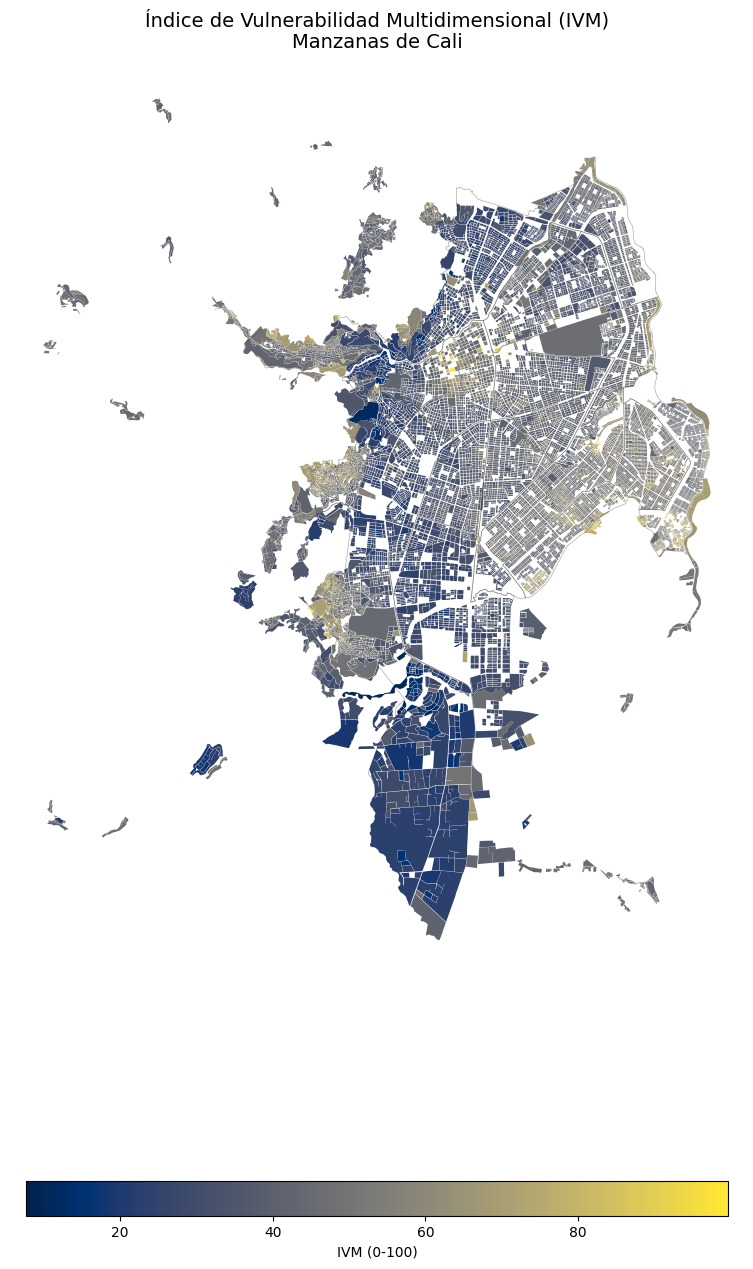

In [15]:
# @title 15. Mapa IVM - Heatmap territorial (cividis)

fig, ax = plt.subplots(1, 1, figsize=(12, 14))

# Filtrar manzanas con IVM calculado
gdf_plot = gdf_base[gdf_base['IVM'].notna()].copy()

gdf_plot.plot(
    column='IVM',
    cmap='cividis',
    legend=True,
    legend_kwds={'label': 'IVM (0-100)', 'orientation': 'horizontal', 'shrink': 0.6},
    ax=ax,
    edgecolor='none',
    linewidth=0.1
)

# Contorno de comunas
gdf_comunas_proj.boundary.plot(ax=ax, color='#333333', linewidth=0.5, alpha=0.4)

ax.set_title('Índice de Vulnerabilidad Multidimensional (IVM)\nManzanas de Cali', fontsize=14)
ax.set_axis_off()
plt.tight_layout()
plt.show()

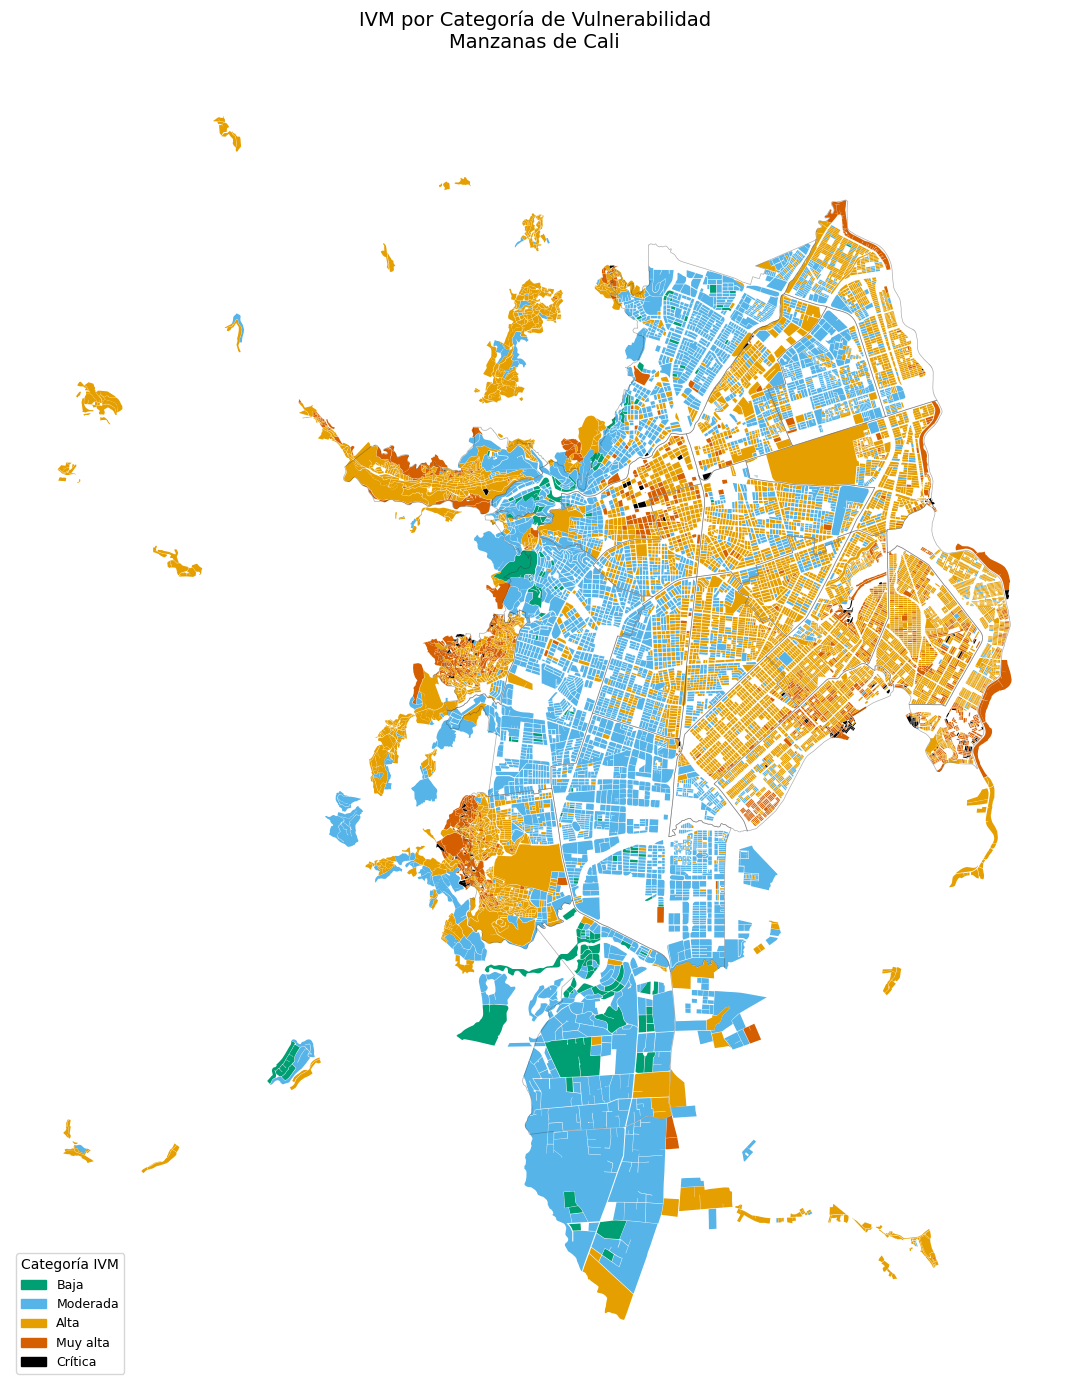

In [16]:
# @title 16. Mapa IVM - Categorías (Okabe-Ito)

fig, ax = plt.subplots(1, 1, figsize=(12, 14))

gdf_plot = gdf_base[gdf_base['IVM'].notna()].copy()

# Orden de categorías
cat_order = ['Baja', 'Moderada', 'Alta', 'Muy alta', 'Crítica']

for cat in cat_order:
    subset = gdf_plot[gdf_plot['cat_IVM'] == cat]
    if len(subset) > 0:
        subset.plot(ax=ax, color=COLORES_IVM[cat], edgecolor='none', linewidth=0.1)

# Contorno comunas
gdf_comunas_proj.boundary.plot(ax=ax, color='#333333', linewidth=0.5, alpha=0.4)

# Leyenda
patches = [mpatches.Patch(color=COLORES_IVM[c], label=c) for c in cat_order]
ax.legend(handles=patches, loc='lower left', fontsize=9, title='Categoría IVM')

ax.set_title('IVM por Categoría de Vulnerabilidad\nManzanas de Cali', fontsize=14)
ax.set_axis_off()
plt.tight_layout()
plt.show()

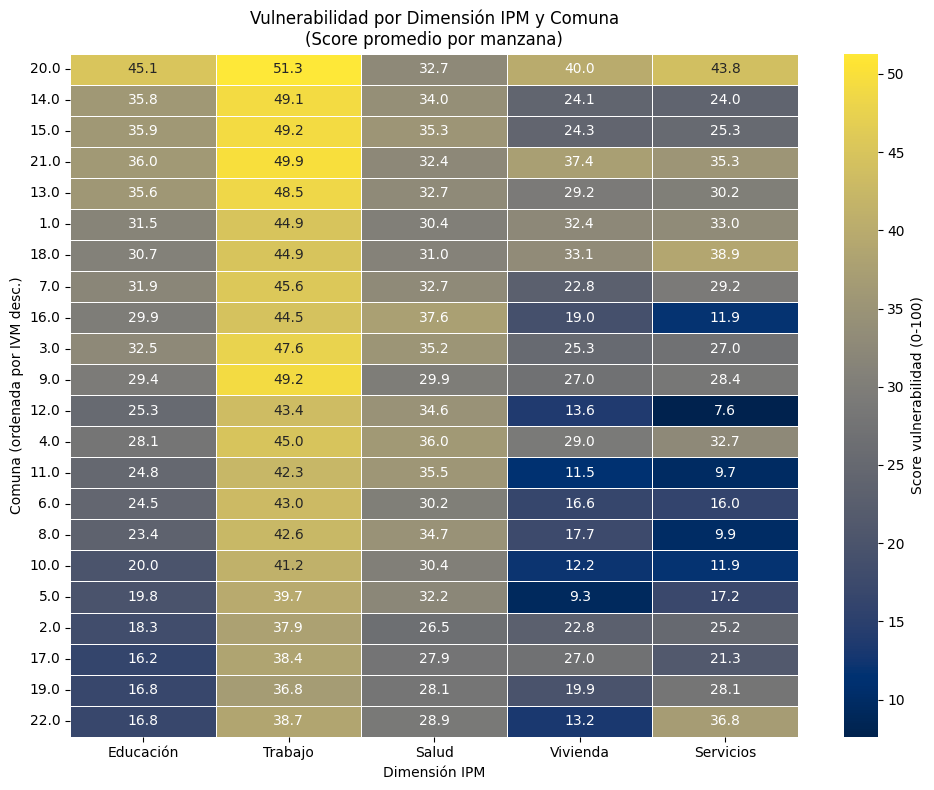

In [17]:
# @title 17. Heatmap IVM por comuna y dimensión (cividis)

# Calcular score promedio por dimensión IPM por comuna
dim_scores = {}
for dim, vars_dim in DIMENSIONES_IPM.items():
    cols = [f'score_{v}' for v in vars_dim if f'score_{v}' in gdf_base.columns]
    if cols:
        dim_scores[dim] = gdf_base.groupby('COMUNA')[cols].mean().mean(axis=1)

df_heatmap = pd.DataFrame(dim_scores)
df_heatmap['IVM'] = gdf_base.groupby('COMUNA')['IVM'].mean()

# Convertir índice a entero y ordenar ascendente (comuna 1 a 22)
df_heatmap.index = df_heatmap.index.astype(int)
df_heatmap = df_heatmap.sort_index(ascending=True)

# Heatmap
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    df_heatmap.drop(columns=['IVM']),
    cmap='cividis',
    annot=True,
    fmt='.1f',
    linewidths=0.5,
    ax=ax,
    cbar_kws={'label': 'Score vulnerabilidad (0-100)'}
)
ax.set_title('Vulnerabilidad por Dimensión IPM y Comuna\n(Score promedio por manzana)', fontsize=12)
ax.set_xlabel('Dimensión IPM')
ax.set_ylabel('Comuna')
plt.tight_layout()
plt.show()

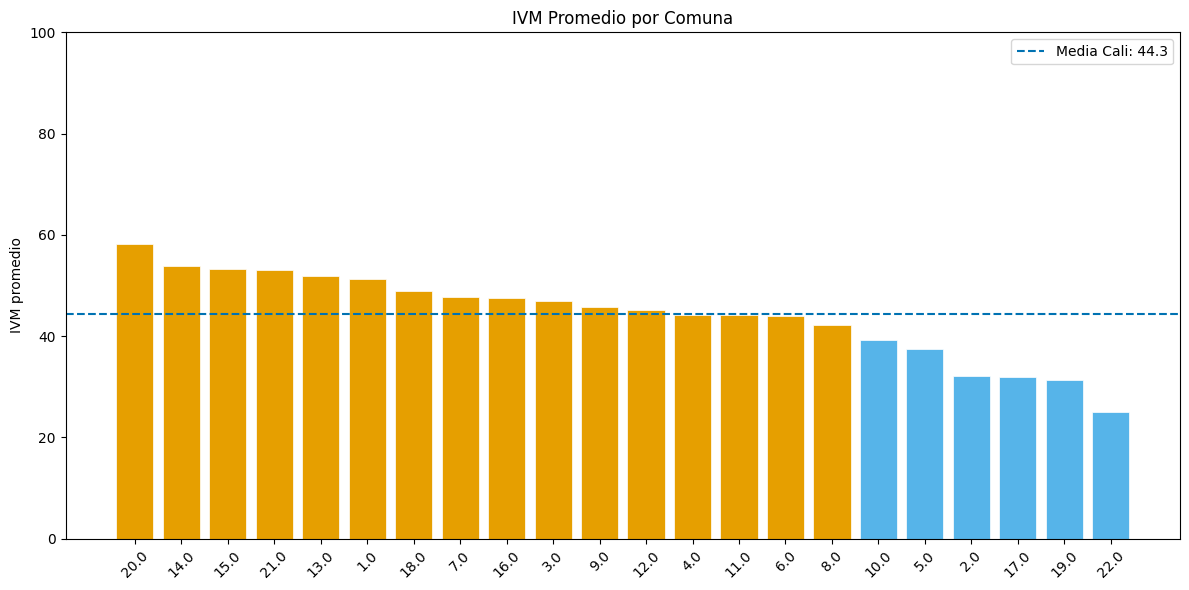

In [18]:
# @title 18. IVM promedio por comuna (barras Okabe-Ito)

ivm_comuna = gdf_base.groupby('COMUNA')['IVM'].mean().sort_values(ascending=False).dropna()

fig, ax = plt.subplots(figsize=(12, 6))

# Colorear según categoría
colores = []
for val in ivm_comuna.values:
    cat = clasificar_ivm(val)
    colores.append(COLORES_IVM[cat])

bars = ax.bar(range(len(ivm_comuna)), ivm_comuna.values, color=colores, edgecolor='white', linewidth=0.5)
ax.set_xticks(range(len(ivm_comuna)))
ax.set_xticklabels([f'C{int(c)}' if str(c).isdigit() else str(c) for c in ivm_comuna.index], rotation=45)
ax.set_ylabel('IVM promedio')
ax.set_title('IVM Promedio por Comuna', fontsize=12)
ax.axhline(y=ivm_comuna.mean(), color=OKABE_ITO[4], linestyle='--', linewidth=1.5, label=f'Media Cali: {ivm_comuna.mean():.1f}')
ax.legend()
ax.set_ylim(0, 100)
plt.tight_layout()
plt.show()

In [19]:
# @title 19. IVM en zonas de interés (Barrio Obrero y Roosevelt)

# Cargar polígonos de zonas
gdf_obrero = gpd.read_file(os.path.join(
    DATA_DIR, 'Geojson_Barrio_Obrero', 'Geojson_Barrio_Obrero.geojson'
)).to_crs(gdf_base.crs)

gdf_roosevelt = gpd.read_file(os.path.join(
    DATA_DIR, 'Geojson_Roosevelt', 'tramos_Roosevelt_Buffer_100.geojson'
)).to_crs(gdf_base.crs)

# Filtrar manzanas por zona (spatial join)
gdf_centroids = gdf_base.copy()
gdf_centroids['geometry'] = gdf_centroids.geometry.centroid

# Barrio Obrero
mzn_obrero = gpd.sjoin(gdf_centroids, gdf_obrero[['geometry']], how='inner', predicate='within')
idx_obrero = mzn_obrero.index

# Roosevelt
mzn_roosevelt = gpd.sjoin(gdf_centroids, gdf_roosevelt[['geometry']], how='inner', predicate='within')
idx_roosevelt = mzn_roosevelt.index

print(f'Manzanas en Barrio Obrero: {len(idx_obrero)}')
print(f'  IVM promedio: {gdf_base.loc[idx_obrero, "IVM"].mean():.2f}')
print(f'  Categoría predominante: {gdf_base.loc[idx_obrero, "cat_IVM"].mode().iloc[0] if len(idx_obrero) > 0 else "N/A"}')
print()
print(f'Manzanas en Roosevelt: {len(idx_roosevelt)}')
print(f'  IVM promedio: {gdf_base.loc[idx_roosevelt, "IVM"].mean():.2f}')
print(f'  Categoría predominante: {gdf_base.loc[idx_roosevelt, "cat_IVM"].mode().iloc[0] if len(idx_roosevelt) > 0 else "N/A"}')

Manzanas en Barrio Obrero: 9
  IVM promedio: 49.47
  Categoría predominante: Alta

Manzanas en Roosevelt: 40
  IVM promedio: 34.65
  Categoría predominante: Moderada


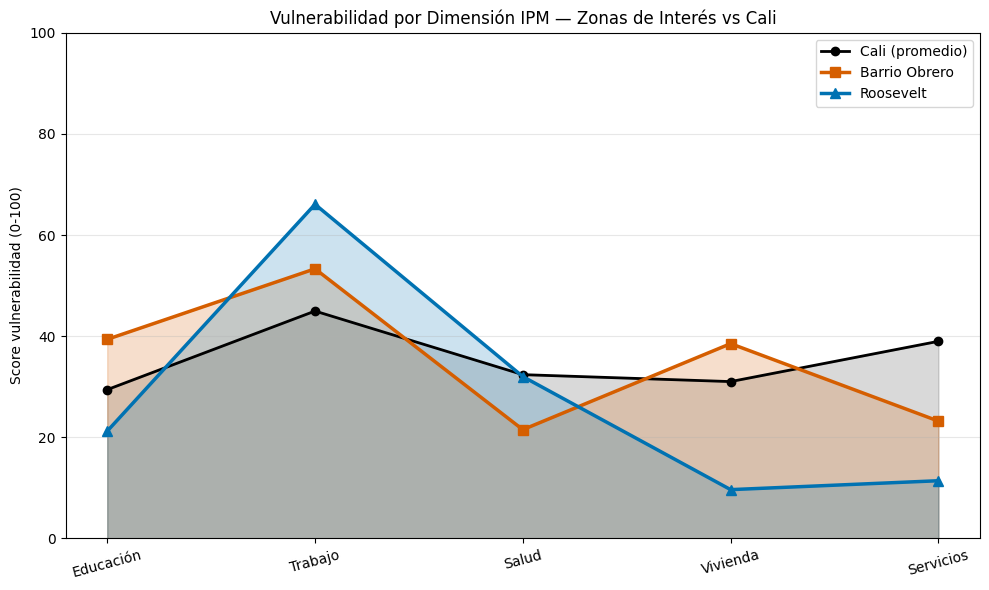

In [20]:
# @title 20. Comparativo IVM por zona (línea + relleno)

# Preparar datos por dimensión para cada zona
dims = list(DIMENSIONES_IPM.keys())

def score_dim_zona(indices, dim):
    vars_dim = DIMENSIONES_IPM[dim]
    cols = [f'score_{v}' for v in vars_dim if f'score_{v}' in gdf_base.columns]
    return gdf_base.loc[indices, cols].mean().mean()

scores_obrero = [score_dim_zona(idx_obrero, d) for d in dims]
scores_roosevelt = [score_dim_zona(idx_roosevelt, d) for d in dims]
scores_cali = [score_dim_zona(gdf_base.index, d) for d in dims]

# Gráfica línea + relleno
fig, ax = plt.subplots(figsize=(10, 6))

x = range(len(dims))

# Relleno Cali (referencia)
ax.fill_between(x, scores_cali, alpha=0.15, color=OKABE_ITO[7], label='_nolegend_')
ax.plot(x, scores_cali, color=OKABE_ITO[7], linewidth=2, marker='o', markersize=6, label='Cali (promedio)')

# Barrio Obrero
ax.fill_between(x, scores_obrero, alpha=0.2, color=OKABE_ITO[5])
ax.plot(x, scores_obrero, color=OKABE_ITO[5], linewidth=2.5, marker='s', markersize=7, label='Barrio Obrero')

# Roosevelt
ax.fill_between(x, scores_roosevelt, alpha=0.2, color=OKABE_ITO[4])
ax.plot(x, scores_roosevelt, color=OKABE_ITO[4], linewidth=2.5, marker='^', markersize=7, label='Roosevelt')

ax.set_xticks(x)
ax.set_xticklabels(dims, rotation=15)
ax.set_ylabel('Score vulnerabilidad (0-100)')
ax.set_title('Vulnerabilidad por Dimensión IPM — Zonas de Interés vs Cali', fontsize=12)
ax.legend(loc='upper right')
ax.set_ylim(0, 100)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

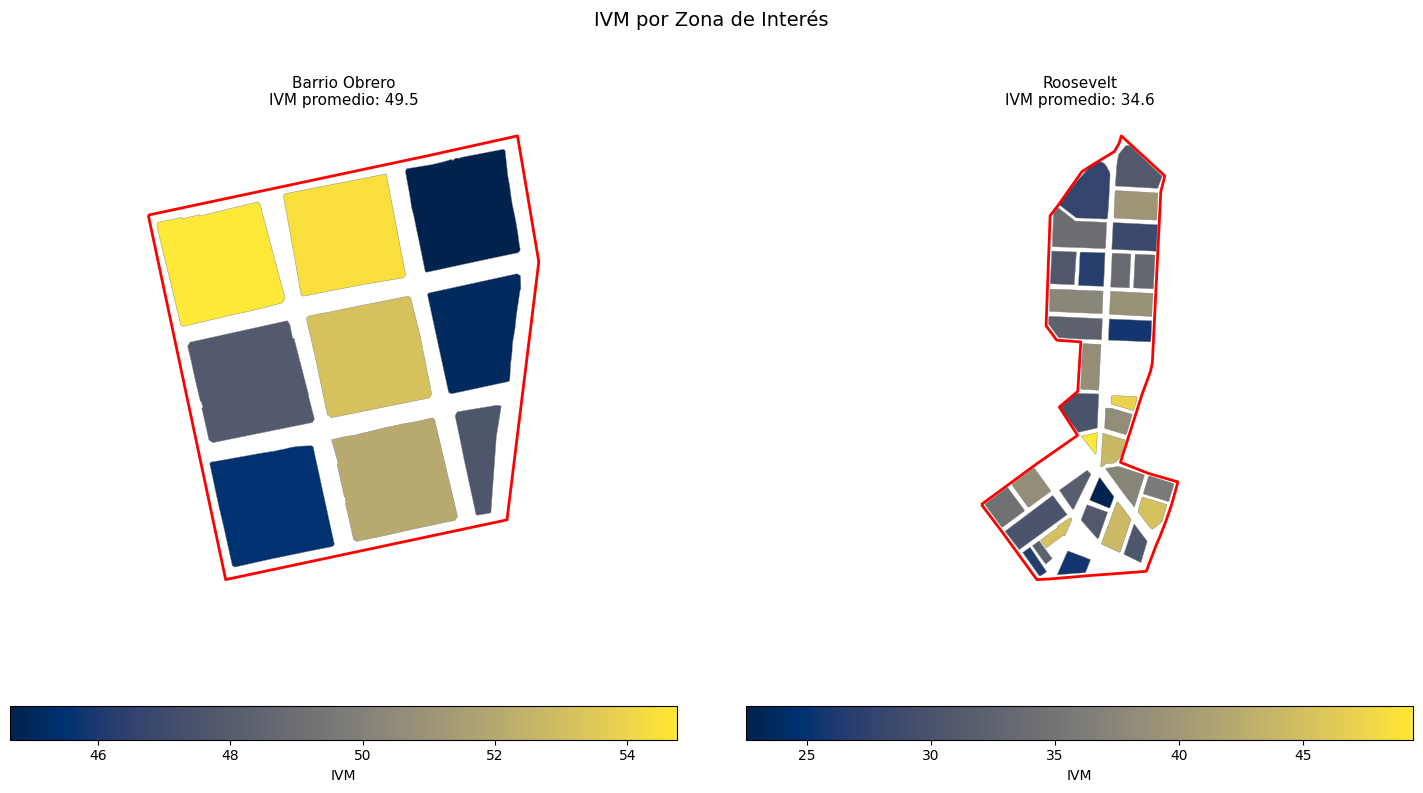

In [21]:
# @title 21. Mapas IVM por zona de interés (cividis + categorías)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Categorías para leyenda
cat_order = ['Baja', 'Moderada', 'Alta', 'Muy alta', 'Crítica']

# Barrio Obrero
ax = axes[0]
gdf_obrero.boundary.plot(ax=ax, color='red', linewidth=2)
gdf_zona_obrero = gdf_base.loc[idx_obrero].copy()
gdf_zona_obrero.plot(
    column='IVM', cmap='cividis', ax=ax, edgecolor='gray', linewidth=0.3,
    legend=True, legend_kwds={'label': 'IVM', 'orientation': 'horizontal', 'shrink': 0.8}
)
# Etiquetar manzanas con valor IVM
for idx, row in gdf_zona_obrero.iterrows():
    if pd.notna(row['IVM']):
        centroid = row['geometry'].centroid
        ax.annotate(f"{row['IVM']:.0f}", xy=(centroid.x, centroid.y),
                    fontsize=5, ha='center', va='center', color='white', fontweight='bold')
ivm_obrero = gdf_zona_obrero['IVM'].mean()
cat_obrero = clasificar_ivm(ivm_obrero)
ax.set_title(f'Barrio Obrero\nIVM promedio: {ivm_obrero:.1f} ({cat_obrero})', fontsize=11)
ax.set_axis_off()

# Roosevelt
ax = axes[1]
gdf_roosevelt.boundary.plot(ax=ax, color='red', linewidth=2)
gdf_zona_roosevelt = gdf_base.loc[idx_roosevelt].copy()
gdf_zona_roosevelt.plot(
    column='IVM', cmap='cividis', ax=ax, edgecolor='gray', linewidth=0.3,
    legend=True, legend_kwds={'label': 'IVM', 'orientation': 'horizontal', 'shrink': 0.8}
)
# Etiquetar manzanas con valor IVM
for idx, row in gdf_zona_roosevelt.iterrows():
    if pd.notna(row['IVM']):
        centroid = row['geometry'].centroid
        ax.annotate(f"{row['IVM']:.0f}", xy=(centroid.x, centroid.y),
                    fontsize=5, ha='center', va='center', color='white', fontweight='bold')
ivm_roosevelt = gdf_zona_roosevelt['IVM'].mean()
cat_roosevelt = clasificar_ivm(ivm_roosevelt)
ax.set_title(f'Roosevelt\nIVM promedio: {ivm_roosevelt:.1f} ({cat_roosevelt})', fontsize=11)
ax.set_axis_off()

plt.suptitle('IVM por Zona de Interés', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [23]:
# @title 23. Top 20 manzanas más vulnerables

top20 = gdf_base.nlargest(20, 'IVM')[[
    'COD_MZN_str', 'COMUNA', 'ics', 'ipm', 'IVM', 'cat_IVM'
]].reset_index(drop=True)

top20.index = top20.index + 1
top20.columns = ['Código Manzana', 'Comuna', 'ICS', 'IPM', 'IVM', 'Categoría']

print('=== Top 20 Manzanas con Mayor Vulnerabilidad ===')
display(top20)

=== Top 20 Manzanas con Mayor Vulnerabilidad ===


,Código Manzana,Comuna,ICS,IPM,IVM,Categoría
1,7600110000000003130112,3.0,0.000000,87.5,99.625000,Crítica
2,7600110000000003120115,3.0,0.578947,78.9,99.305104,Crítica
3,7600110000000018141401,NaN,10.833333,83.3,95.809906,Crítica
4,7600110000000014020524,NaN,9.092308,90.8,94.539887,Crítica
5,7600110000000014030710,14.0,0.416667,75.0,94.451640,Crítica
6,7600110000000014020525,NaN,6.033333,93.3,93.337620,Crítica
7,7600110000000003120216,3.0,7.764706,100.0,93.071695,Crítica
8,7600110000000018141116,NaN,8.400000,86.7,92.387146,Crítica
9,7600110000000021050826,21.0,17.625000,100.0,91.832332,Crítica
10,7600110000000013170249,13.0,10.150000,83.3,91.234337,Crítica


In [24]:
# @title 24. Resumen ejecutivo

print('=' * 60)
print('RESUMEN EJECUTIVO — IVM Cali')
print('=' * 60)
print()
print(f'Total manzanas analizadas: {gdf_base["IVM"].notna().sum():,}')
print(f'IVM promedio Cali: {gdf_base["IVM"].mean():.2f}')
print(f'IVM mediana Cali: {gdf_base["IVM"].median():.2f}')
print()
print('--- Distribución por categoría ---')
dist = gdf_base['cat_IVM'].value_counts()
total = dist.sum()
for cat in ['Baja', 'Moderada', 'Alta', 'Muy alta', 'Crítica']:
    n = dist.get(cat, 0)
    print(f'  {cat:12s}: {n:5,} manzanas ({n/total*100:.1f}%)')
print()
print('--- Zonas de interés ---')
print(f'  Barrio Obrero: IVM = {gdf_base.loc[idx_obrero, "IVM"].mean():.2f} ({len(idx_obrero)} manzanas)')
print(f'  Roosevelt:     IVM = {gdf_base.loc[idx_roosevelt, "IVM"].mean():.2f} ({len(idx_roosevelt)} manzanas)')
print()
print('--- Comunas más vulnerables (top 5) ---')
top_comunas = gdf_base.groupby('COMUNA')['IVM'].mean().nlargest(5)
for comuna, val in top_comunas.items():
    print(f'  Comuna {comuna}: IVM = {val:.2f}')
print()
print('--- Componentes del IVM ---')
print(f'  Score ICS (invertido): {gdf_base["score_ics"].mean():.2f} (peso 40%)')
print(f'  Score IPM global:      {gdf_base["score_ipm"].mean():.2f} (peso 30%)')
print(f'  Score vars críticas:   {gdf_base["score_vars_criticas"].mean():.2f} (peso 30%)')
print()
print('--- Metodología ---')
print('  Normalización: ref_min/ref_max fijos')
print('  ICS: invertido (menor ICS = mayor vulnerabilidad)')
print('  IPM: directo (mayor IPM = mayor vulnerabilidad)')
print('  Escala: 0-100 (mayor = más vulnerable)')
print('=' * 60)

RESUMEN EJECUTIVO — IVM Cali

Total manzanas analizadas: 13,614
IVM promedio Cali: 45.36
IVM mediana Cali: 44.77

--- Distribución por categoría ---
  Baja        :   133 manzanas (0.8%)
  Moderada    : 4,359 manzanas (27.8%)
  Alta        : 7,621 manzanas (48.7%)
  Muy alta    : 1,372 manzanas (8.8%)
  Crítica     :   129 manzanas (0.8%)

--- Zonas de interés ---
  Barrio Obrero: IVM = 49.47 (9 manzanas)
  Roosevelt:     IVM = 34.65 (40 manzanas)

--- Comunas más vulnerables (top 5) ---
  Comuna 20.0: IVM = 58.21
  Comuna 14.0: IVM = 53.75
  Comuna 15.0: IVM = 53.22
  Comuna 21.0: IVM = 53.07
  Comuna 13.0: IVM = 51.96

--- Componentes del IVM ---
  Score ICS (invertido): 70.45 (peso 40%)
  Score IPM global:      15.74 (peso 30%)
  Score vars críticas:   47.47 (peso 30%)

--- Metodología ---
  Normalización: ref_min/ref_max fijos
  ICS: invertido (menor ICS = mayor vulnerabilidad)
  IPM: directo (mayor IPM = mayor vulnerabilidad)
  Escala: 0-100 (mayor = más vulnerable)


In [25]:
# @title 25. Exportar resultados

# Exportar GeoJSON con IVM
output_dir = os.path.join(BASE_DIR, 'indice_Pobreza', 'outputs')
os.makedirs(output_dir, exist_ok=True)

# Seleccionar columnas para exportar
cols_export = ['COD_MZN_str', 'COMUNA', 'ics', 'ipm', 'score_ics', 'score_ipm',
               'score_vars_criticas', 'IVM', 'cat_IVM', 'geometry']
gdf_export = gdf_base[gdf_base['IVM'].notna()][cols_export].copy()
gdf_export = gdf_export.rename(columns={'COD_MZN_str': 'COD_MZN'})

# Convertir a WGS84 para GeoJSON
gdf_export_wgs = gdf_export.to_crs(epsg=4326)
geojson_path = os.path.join(output_dir, 'IVM_manzanas_cali.geojson')
gdf_export_wgs.to_file(geojson_path, driver='GeoJSON')
print(f'GeoJSON exportado: {geojson_path}')

# Exportar resumen por comuna a CSV
resumen_comuna = gdf_base.groupby('COMUNA').agg(
    IVM_mean=('IVM', 'mean'),
    IVM_median=('IVM', 'median'),
    ICS_mean=('ics', 'mean'),
    IPM_mean=('ipm', 'mean'),
    n_manzanas=('IVM', 'count')
).round(2).sort_values('IVM_mean', ascending=False)

csv_path = os.path.join(output_dir, 'IVM_resumen_comunas.csv')
resumen_comuna.to_csv(csv_path)
print(f'CSV exportado: {csv_path}')
print(f'\nTotal manzanas exportadas: {len(gdf_export):,}')

GeoJSON exportado: Pobreza_multidimensional_y_condicion_social/indice_Pobreza/outputs/IVM_manzanas_cali.geojson
CSV exportado: Pobreza_multidimensional_y_condicion_social/indice_Pobreza/outputs/IVM_resumen_comunas.csv

Total manzanas exportadas: 13,614
